In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
#9m question

df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

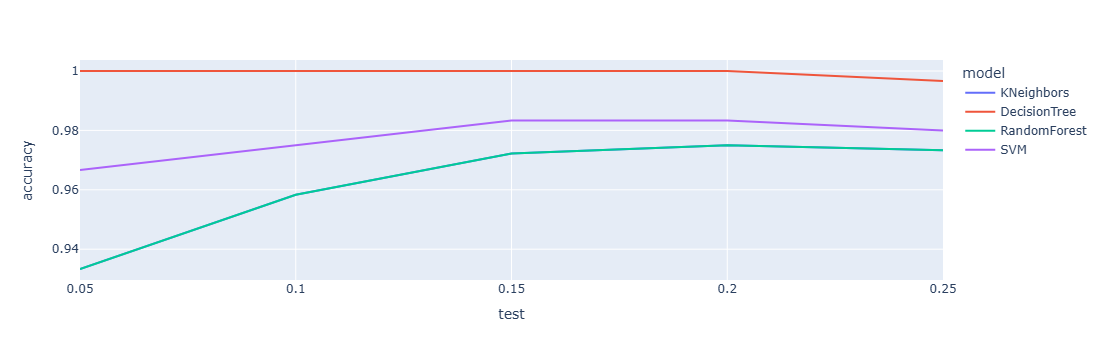

<Figure size 1000x800 with 0 Axes>

In [35]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default='jupyterlab'
plt.figure(figsize=(10,8))
df = df.dropna()
x = pd.get_dummies(df.drop(['depression_label'] , axis=1) , drop_first=True)
y = df['depression_label']

size=[0.05 , 0.10 , 0.15 , 0.20 , 0.25]
d = {'model':[] , 'accuracy':[] , 'test':[]}

for i in size:
    x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=i , random_state=42)
    
    d['model'].append('KNeighbors')
    d['test'].append(i)
    knn = KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train , y_train)
    d['accuracy'].append(accuracy_score(y_test ,knn.predict(x_test)))

    d['model'].append('DecisionTree')
    d['test'].append(i)
    dt = DecisionTreeClassifier(criterion='entropy' , max_depth=4 , random_state=42)
    dt.fit(x_train , y_train)
    d['accuracy'].append(accuracy_score(y_test , dt.predict(x_test)))

    d['model'].append('RandomForest')
    d['test'].append(i)
    rf = RandomForestClassifier(n_estimators=100 , max_depth=4 , random_state=42)
    rf.fit(x_train,y_train)
    d['accuracy'].append(accuracy_score(y_test , rf.predict(x_test)))

    d['model'].append('SVM')
    d['test'].append(i)
    svm = SVC(C=10 , kernel='rbf' , random_state=42)
    svm.fit(x_train , y_train)
    d['accuracy'].append(accuracy_score(y_test , svm.predict(x_test)))

new = pd.DataFrame(d)
px.line(data_frame=new , x='test' , y='accuracy' , color='model')

In [36]:
new

,model,accuracy,test
0,KNeighbors,0.933333,0.05
1,DecisionTree,1.000000,0.05
2,RandomForest,0.933333,0.05
3,SVM,0.966667,0.05
4,KNeighbors,0.958333,0.10
5,DecisionTree,1.000000,0.10
6,RandomForest,0.958333,0.10
7,SVM,0.975000,0.10
8,KNeighbors,0.972222,0.15
9,DecisionTree,1.000000,0.15


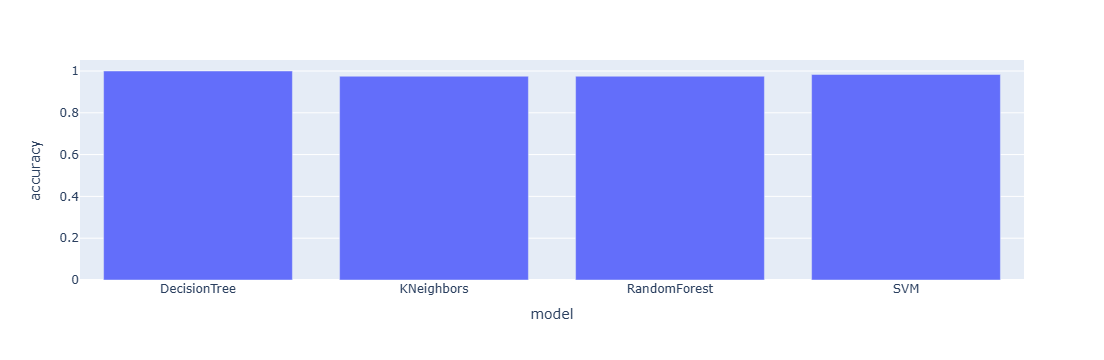

In [6]:
result = new.groupby('model')['accuracy'].max().reset_index()
px.bar(data_frame=result , x='model' , y='accuracy')

In [11]:
#Task 2
df = pd.read_csv('created_house_price_prediction.csv')
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Garage', 'YearBuilt', 'Location',
       'Price'],
      dtype='object')

In [12]:
df.head()

,Area,Bedrooms,Bathrooms,Garage,YearBuilt,Location,Price
0,8000.0,3.0,2.0,1.0,2004.0,Lagos,105402678.0
1,8100.0,2.0,2.0,1.0,2013.0,Kaduna,62530695.0
2,8200.0,2.0,1.0,0.0,2023.0,Kano,71488309.0
3,8300.0,3.0,1.0,0.0,2006.0,Kano,70608894.0
4,8400.0,3.0,2.0,1.0,2003.0,Lagos,107029977.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       1999 non-null   float64
 1   Bedrooms   1999 non-null   float64
 2   Bathrooms  1999 non-null   float64
 3   Garage     1999 non-null   float64
 4   YearBuilt  1999 non-null   float64
 5   Location   1999 non-null   object 
 6   Price      1999 non-null   float64
dtypes: float64(6), object(1)
memory usage: 112.2+ KB


In [14]:
df = df.dropna()
x = pd.get_dummies(df.drop(['Price'] ,axis=1) , drop_first=True)
y = df['Price']

d={'degree':[] , 'r2':[] , 'mse':[]}
for i in range(1,6):
    x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

    poly = PolynomialFeatures(degree=i)
    d['degree'].append(i)
    x_poly_train = poly.fit_transform(x_train)
    x_poly_test = poly.transform(x_test)

    model = LinearRegression()
    model.fit(x_poly_train , y_train)

    d['r2'].append(r2_score(y_test , model.predict(x_poly_test)))
    d['mse'].append(mean_squared_error(y_test , model.predict(x_poly_test)))
new = pd.DataFrame(d)

In [24]:
d = new[new['r2'].max() == new['r2']]['degree'].reset_index()['degree']

In [28]:
size = [0.05 , 0.10 , 0.15 , 0.20 ,0.25]
d = {'model':[] , 'r2':[] , 'mse':[] , 'size':[]}
for i in size:
    x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=i , random_state=42)

    d['model'].append('LinearRegression')
    d['size'].append(i)
    model = LinearRegression()
    model.fit(x_train,y_train)
    d['r2'].append(r2_score(y_test , model.predict(x_test)))
    d['mse'].append(mean_squared_error(y_test , model.predict(x_test)))

    d['model'].append('PolynomialRegression')
    d['size'].append(i)

    poly = PolynomialFeatures(degree=5)
    x_poly_train = poly.fit_transform(x_train)
    x_poly_test = poly.transform(x_test)

    model = LinearRegression()
    model.fit(x_poly_train , y_train)

    d['r2'].append(r2_score(y_test , model.predict(x_poly_test)))
    d['mse'].append(mean_squared_error(y_test , model.predict(x_poly_test)))
new = pd.DataFrame(d)

In [29]:
new

,model,r2,mse,size
0,LinearRegression,0.268646,5.655044e+14,0.05
1,PolynomialRegression,0.935630,4.977298e+13,0.05
2,LinearRegression,0.178949,4.047876e+14,0.10
3,PolynomialRegression,0.918813,4.002601e+13,0.10
4,LinearRegression,0.230288,4.316472e+14,0.15
5,PolynomialRegression,0.924274,4.246651e+13,0.15
6,LinearRegression,0.214250,4.011141e+14,0.20
7,PolynomialRegression,0.922905,3.935610e+13,0.20
8,LinearRegression,0.178664,3.994572e+14,0.25
9,PolynomialRegression,0.920741,3.854784e+13,0.25


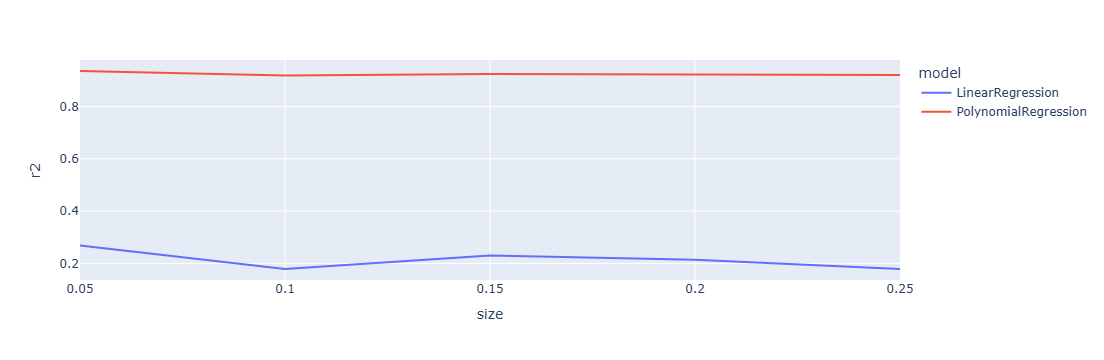

In [30]:
px.line(data_frame=new , x='size' , y='r2' , color='model')

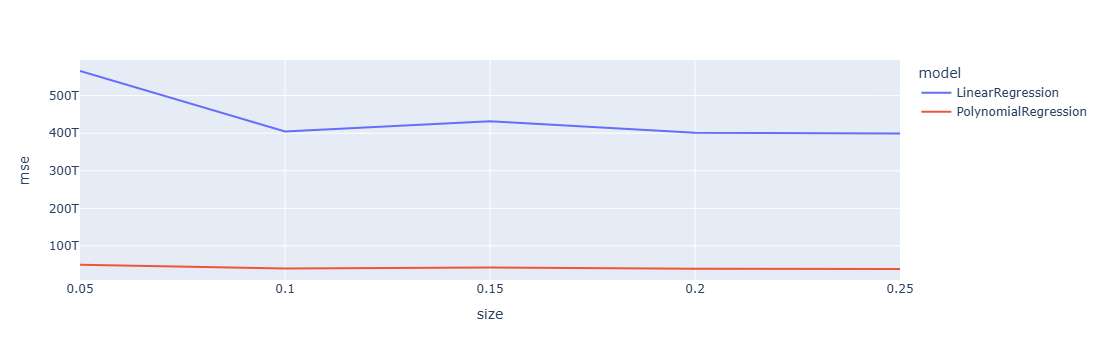

In [31]:
px.line(data_frame=new , x='size' , y='mse' , color='model')